# 🎯 YOLO Object Detection — Interactive Demo

This notebook walks you through:
1. Installing dependencies
2. Downloading a pretrained YOLOv8 model
3. Running detection on a sample image
4. Visualising results

In [ ]:
# ── 1. Install dependencies (run once) ─────────────────────────────
!pip install ultralytics opencv-python matplotlib

In [ ]:
import sys, os
from pathlib import Path

# Make sure the project root is on the path
ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

print('Importé avec Succès')

Importé avec Succès


In [ ]:
# Load a pretrained YOLOv8 model 
# Downloads automatically on first run (~6 MB for yolov8n)

model = YOLO('yolov8n.pt')
print(f'Model loaded: {model.info()}')

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Model loaded: (129, 3157200, 0, 8.8575488)


In [ ]:
# Run detection on a sample image 
# Replace with your own image path
IMAGE_PATH = '../data/images/test.jpg'

# If no image, download a sample
if not Path(IMAGE_PATH).exists():
    import urllib.request
    Path('../data/images').mkdir(parents=True, exist_ok=True)
    url = 'https://ultralytics.com/images/bus.jpg'
    urllib.request.urlretrieve(url, IMAGE_PATH)
    print(f'Sample image downloaded → {IMAGE_PATH}')

results = model.predict(source=IMAGE_PATH, conf=0.25, verbose=False)
result = results[0]
print(f'Detected {len(result.boxes)} object(s)')

Detected 6 object(s)


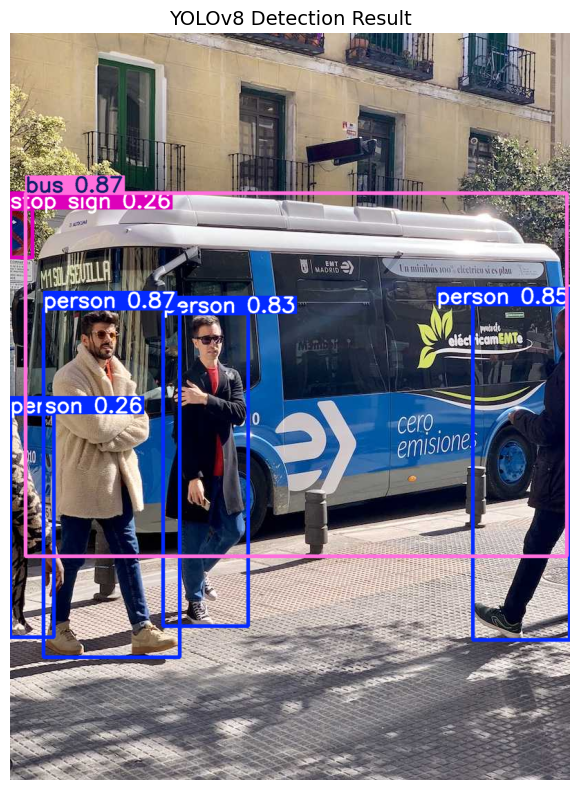

In [ ]:
# Visualise results
annotated = result.plot()   # BGR numpy array
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('YOLOv8 Detection Result', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Print detected objects 
names = model.names
print(f"{'Class':<20} {'Confidence':>10} {'Bounding Box (xyxy)'}")
print('-' * 60)
for box in result.boxes:
    cls   = names[int(box.cls[0])]
    conf  = float(box.conf[0])
    xyxy  = [round(v, 1) for v in box.xyxy[0].tolist()]
    print(f"{cls:<20} {conf:>10.2%} {xyxy}")

In [ ]:
# Compare model sizes (speed vs accuracy)
import time

variants = ['yolov8n', 'yolov8s']
timings = {}

for variant in variants:
    m = YOLO(f'{variant}.pt')
    t0 = time.time()
    for _ in range(5):
        m.predict(source=IMAGE_PATH, conf=0.25, verbose=False)
    avg = (time.time() - t0) / 5 * 1000
    timings[variant] = avg
    print(f'{variant}: {avg:.1f} ms/image')

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(timings.keys()), list(timings.values()), color='steelblue')
ax.set_xlabel('Inference time (ms)')
ax.set_title('Model Speed Comparison')
plt.tight_layout()
plt.show()